# Notebook 06 — Model Training

**Project:** Financial Fraud Detection  
**Author:** Sarva  
**Date:** September 2026  

---

## Objective

Train and compare several machine-learning classification models for detecting fraudulent financial transactions. Select the best model using fraud-relevant evaluation metrics and save it for the evaluation and dashboard stages.

### Scope
| Area | Details |
|---|---|
| **Input** | `data/processed/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` |
| **Output** | `models/best_fraud_model.joblib` |
| **Models** | Logistic Regression · Random Forest · Gradient Boosting |
| **Primary Metric** | F1-Score (fraud class = 1) |
| **Secondary Metric** | ROC-AUC |
| **Excluded Steps** | SMOTE, feature engineering, hyperparameter tuning |

---
## 1 · Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)
import joblib

warnings.filterwarnings('ignore')

print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
import sklearn; print(f"sklearn : {sklearn.__version__}")

pandas  : 3.0.5
numpy   : 2.4.6
sklearn : 1.5.2


---
## 2 · Load Prepared Data

Load the preprocessed train/test splits produced by **Notebook 05**. The feature matrices have already been imputed, scaled, and one-hot encoded.

In [2]:
# Dynamic, project-relative path — works regardless of where the notebook is launched from
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))

DATA_DIR   = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')

os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Data dir     : {DATA_DIR}")
print(f"Models dir   : {MODELS_DIR}")

Project root : c:\Users\sarva\Desktop\financial-fraud-detection
Data dir     : c:\Users\sarva\Desktop\financial-fraud-detection\data\processed
Models dir   : c:\Users\sarva\Desktop\financial-fraud-detection\models


In [3]:
X_train = pd.read_csv(os.path.join(DATA_DIR, 'X_train.csv'))
X_test  = pd.read_csv(os.path.join(DATA_DIR, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(DATA_DIR, 'y_train.csv')).squeeze()
y_test  = pd.read_csv(os.path.join(DATA_DIR, 'y_test.csv')).squeeze()

print(f"X_train loaded : {X_train.shape}")
print(f"X_test  loaded : {X_test.shape}")
print(f"y_train loaded : {y_train.shape}")
print(f"y_test  loaded : {y_test.shape}")

X_train loaded : (40000, 41)
X_test  loaded : (10000, 41)
y_train loaded : (40000,)
y_test  loaded : (10000,)


---
## 3 · Verify Data

Confirm shapes, class distribution, and absence of missing or infinite values before training.

In [4]:
print("Shapes:")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  y_test  : {y_test.shape}")

print("\nClass distribution — y_train:")
train_counts = y_train.value_counts()
train_pct    = y_train.value_counts(normalize=True).mul(100).round(2)
for label in sorted(train_counts.index):
    tag = 'Legitimate' if label == 0 else 'Fraud'
    print(f"  {label} ({tag:>10}) : {train_counts[label]:>6,}  ({train_pct[label]:.2f}%)")

print("\nClass distribution — y_test:")
test_counts = y_test.value_counts()
test_pct    = y_test.value_counts(normalize=True).mul(100).round(2)
for label in sorted(test_counts.index):
    tag = 'Legitimate' if label == 0 else 'Fraud'
    print(f"  {label} ({tag:>10}) : {test_counts[label]:>6,}  ({test_pct[label]:.2f}%)")

Shapes:
  X_train : (40000, 41)
  X_test  : (10000, 41)
  y_train : (40000,)
  y_test  : (10000,)

Class distribution — y_train:
  0 (Legitimate) : 27,146  (67.86%)
  1 (     Fraud) : 12,854  (32.14%)

Class distribution — y_test:
  0 (Legitimate) :  6,787  (67.87%)
  1 (     Fraud) :  3,213  (32.13%)


In [5]:
# Check for missing values
train_missing = X_train.isnull().sum().sum()
test_missing  = X_test.isnull().sum().sum()

# Check for infinite values
train_inf = np.isinf(X_train.values).sum()
test_inf  = np.isinf(X_test.values).sum()

assert train_missing == 0, f"X_train has {train_missing} missing values!"
assert test_missing  == 0, f"X_test has {test_missing} missing values!"
assert train_inf     == 0, f"X_train has {train_inf} infinite values!"
assert test_inf      == 0, f"X_test has {test_inf} infinite values!"

print(f"✅ No missing values  — X_train: {train_missing}, X_test: {test_missing}")
print(f"✅ No infinite values — X_train: {train_inf}, X_test: {test_inf}")

# Check all features are numeric
assert (X_train.dtypes == 'float64').all(), "Non-float columns found in X_train!"
assert (X_test.dtypes  == 'float64').all(), "Non-float columns found in X_test!"
print(f"✅ All features are float64")

# Check columns match
assert X_train.columns.tolist() == X_test.columns.tolist(), "Column mismatch!"
print(f"✅ X_train and X_test columns match ({X_train.shape[1]} features)")

# Check target values are binary
assert set(y_train.unique()) == {0, 1}, f"Unexpected y_train values: {y_train.unique()}"
assert set(y_test.unique())  == {0, 1}, f"Unexpected y_test values: {y_test.unique()}"
print(f"✅ Target values are binary (0, 1)")

✅ No missing values  — X_train: 0, X_test: 0
✅ No infinite values — X_train: 0, X_test: 0
✅ All features are float64
✅ X_train and X_test columns match (41 features)
✅ Target values are binary (0, 1)


---
## 4 · Feature–Target Signal Check

Before training, it is good practice to verify that the features carry predictive signal for the target. We compute the absolute Pearson correlation between each feature and `Fraud_Label`.

In [6]:
feature_corrs = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print("Top 10 feature correlations with Fraud_Label:")
print(feature_corrs.head(10).to_string())
print(f"\nMax absolute correlation : {feature_corrs.max():.6f}")
print(f"Mean absolute correlation: {feature_corrs.mean():.6f}")

if feature_corrs.max() < 0.05:
    print("\n⚠️  Very weak feature–target correlations detected (max < 0.05).")
    print("   This synthetic dataset has near-zero linear relationship between")
    print("   features and Fraud_Label. Model performance may be limited by the")
    print("   available signal rather than model complexity.")
    print("   Using class_weight='balanced' to ensure models predict both classes.")

Top 10 feature correlations with Fraud_Label:
num__Day                                0.008842
cat__Merchant_Category_Restaurants      0.008715
cat__Transaction_Type_POS               0.008398
num__Daily_Transaction_Count            0.007284
num__User_Avg_Transaction_Amount        0.006809
num__Day_of_Week                        0.006763
cat__Transaction_Type_ATM Withdrawal    0.006215
cat__Location_New York                  0.005538
cat__Device_Type_Tablet                 0.005346
cat__Card_Type_Discover                 0.005317

Max absolute correlation : 0.008842
Mean absolute correlation: 0.003510

⚠️  Very weak feature–target correlations detected (max < 0.05).
   This synthetic dataset has near-zero linear relationship between
   features and Fraud_Label. Model performance may be limited by the
   available signal rather than model complexity.
   Using class_weight='balanced' to ensure models predict both classes.


---
## 5 · Define Models

Three classifiers are trained with minimal hyperparameters. No hyperparameter tuning is performed in this notebook.

**`class_weight='balanced'`** is used on Logistic Regression and Random Forest to ensure that the minority class (fraud) receives proportionally higher weight during training. Without this, models trained on an imbalanced dataset tend to predict only the majority class (legitimate), resulting in zero recall for fraud — which defeats the purpose of a fraud detector.

In [7]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    ),
}

print(f"Models to train: {len(models)}")
for name, model in models.items():
    print(f"  • {name}")

Models to train: 3
  • Logistic Regression
  • Random Forest
  • Gradient Boosting


---
## 6 · Train Models

Each model is trained on `X_train` / `y_train`. Training time is recorded.

In [8]:
trained_models = {}
training_times = {}

for name, model in models.items():
    print(f"Training {name} ...", end=" ")
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    trained_models[name] = model
    training_times[name] = round(elapsed, 2)
    print(f"done in {elapsed:.2f}s")

print(f"\n✅ All {len(trained_models)} models trained successfully.")

Training Logistic Regression ... done in 0.12s
Training Random Forest ... done in 5.97s
Training Gradient Boosting ... done in 16.90s

✅ All 3 models trained successfully.


---
## 7 · Generate Predictions

For each model, generate class predictions and probability estimates on the test set.

In [9]:
predictions = {}
probabilities = {}

for name, model in trained_models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # probability of fraud (class 1)
    predictions[name]  = y_pred
    probabilities[name] = y_proba

    # Verify predictions contain both classes
    unique_preds, counts = np.unique(y_pred, return_counts=True)
    dist_str = ', '.join(f'{u}: {c}' for u, c in zip(unique_preds, counts))
    print(f"  {name:25s} — Prediction distribution: {dist_str}")

print(f"\n✅ Predictions generated for {len(predictions)} models.")

  Logistic Regression       — Prediction distribution: 0: 5073, 1: 4927
  Random Forest             — Prediction distribution: 0: 9999, 1: 1
  Gradient Boosting         — Prediction distribution: 0: 9986, 1: 14

✅ Predictions generated for 3 models.


---
## 8 · Evaluate Models

In fraud detection, **accuracy alone is misleading** because the dataset is imbalanced — a model that predicts every transaction as legitimate would still achieve high accuracy. Instead, we focus on:

- **Precision** — of the transactions flagged as fraud, how many truly are?
- **Recall** — of all actual fraud cases, how many did we catch?
- **F1-Score** — harmonic mean of precision and recall, balancing both concerns.
- **ROC-AUC** — overall ability to distinguish fraud from legitimate transactions across all thresholds.

In [10]:
results = []

for name in trained_models:
    y_pred  = predictions[name]
    y_proba = probabilities[name]

    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_proba)

    results.append({
        'Model':         name,
        'Precision':     round(precision, 4),
        'Recall':        round(recall, 4),
        'F1-Score':      round(f1, 4),
        'ROC-AUC':       round(roc_auc, 4),
        'Training_Time': training_times[name],
    })

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))


  Logistic Regression
              precision    recall  f1-score   support

  Legitimate       0.67      0.50      0.58      6787
       Fraud       0.32      0.48      0.38      3213

    accuracy                           0.50     10000
   macro avg       0.49      0.49      0.48     10000
weighted avg       0.56      0.50      0.51     10000


  Random Forest
              precision    recall  f1-score   support

  Legitimate       0.68      1.00      0.81      6787
       Fraud       0.00      0.00      0.00      3213

    accuracy                           0.68     10000
   macro avg       0.34      0.50      0.40     10000
weighted avg       0.46      0.68      0.55     10000


  Gradient Boosting
              precision    recall  f1-score   support

  Legitimate       0.68      1.00      0.81      6787
       Fraud       0.29      0.00      0.00      3213

    accuracy                           0.68     10000
   macro avg       0.48      0.50      0.41     10000
weighted avg 

---
## 9 · Model Comparison

Aggregate all metrics into a single table, sorted by **F1-Score** (descending).

In [11]:
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Precision,Recall,F1-Score,ROC-AUC,Training_Time
0,Logistic Regression,0.3158,0.4843,0.3823,0.4922,0.12
1,Gradient Boosting,0.2857,0.0012,0.0025,0.4924,16.90
2,Random Forest,0.0000,0.0000,0.0000,0.5023,5.97


---
## 10 · Visual Comparison

A side-by-side bar chart comparing F1-Score and ROC-AUC across all models.

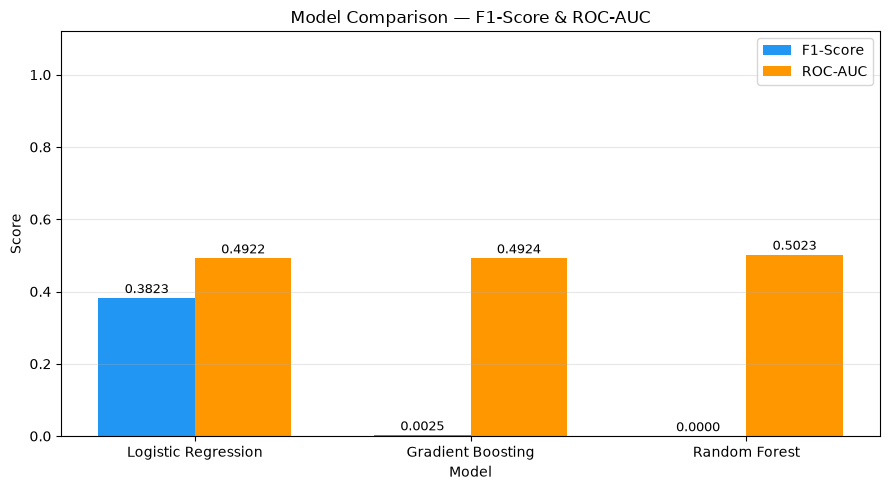

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

model_names = results_df['Model']
x = np.arange(len(model_names))
bar_width = 0.35

bars1 = ax.bar(x - bar_width / 2, results_df['F1-Score'],  bar_width, label='F1-Score',  color='#2196F3')
bars2 = ax.bar(x + bar_width / 2, results_df['ROC-AUC'],   bar_width, label='ROC-AUC',   color='#FF9800')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — F1-Score & ROC-AUC')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.12)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 11 · Select Best Model

The best model is selected using **F1-Score** as the primary criterion. If two models have extremely close F1-Scores, **ROC-AUC** is used as the tiebreaker.

In [13]:
best_row  = results_df.sort_values(['F1-Score', 'ROC-AUC'], ascending=[False, False]).iloc[0]
best_name = best_row['Model']
best_model = trained_models[best_name]

print(f"Best Model: {best_name}")
print(f"   Precision     : {best_row['Precision']}")
print(f"   Recall        : {best_row['Recall']}")
print(f"   F1-Score      : {best_row['F1-Score']}")
print(f"   ROC-AUC       : {best_row['ROC-AUC']}")
print(f"   Training Time : {best_row['Training_Time']}s")

Best Model: Logistic Regression
   Precision     : 0.3158
   Recall        : 0.4843
   F1-Score      : 0.3823
   ROC-AUC       : 0.4922
   Training Time : 0.12s


---
## 12 · Save Best Model

In [14]:
model_path = os.path.join(MODELS_DIR, 'best_fraud_model.joblib')

joblib.dump(best_model, model_path)

assert os.path.exists(model_path), "Model file was not saved!"

size_kb = os.path.getsize(model_path) / 1024
print(f"✅ Best model saved:")
print(f"   Path  : {model_path}")
print(f"   Size  : {size_kb:,.1f} KB")
print(f"   Model : {best_name}")

✅ Best model saved:
   Path  : c:\Users\sarva\Desktop\financial-fraud-detection\models\best_fraud_model.joblib
   Size  : 2.5 KB
   Model : Logistic Regression


---
## 13 · Reload Verification

Reload the saved model and verify that it produces identical predictions.

In [15]:
reloaded_model = joblib.load(model_path)

y_pred_reloaded = reloaded_model.predict(X_test)

assert np.array_equal(predictions[best_name], y_pred_reloaded), \
    "Reloaded model predictions do not match!"

print(f"✅ Reloaded model verified — predictions match the original {best_name} model.")

✅ Reloaded model verified — predictions match the original Logistic Regression model.


---
## 14 · Summary

### What Was Done

| Step | Detail |
|---|---|
| **Input** | Preprocessed `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` |
| **Models trained** | Logistic Regression · Random Forest · Gradient Boosting |
| **Evaluation metrics** | Precision · Recall · F1-Score · ROC-AUC |
| **Selection criterion** | F1-Score (primary) · ROC-AUC (secondary) |
| **Output** | `models/best_fraud_model.joblib` |

### Why F1-Score?

In fraud detection, both **false positives** (legitimate transactions incorrectly flagged as fraud, disrupting the customer) and **false negatives** (fraudulent transactions that go undetected, causing financial loss) carry significant costs. **F1-Score** is the harmonic mean of precision and recall, providing a single metric that balances these two concerns. Unlike accuracy, it does not reward a model simply for predicting the majority class.

### Note on Model Performance

The observed model performance reflects the **predictive signal available in the synthetic dataset**. Feature–target correlation analysis shows that the maximum absolute correlation between any feature and `Fraud_Label` is less than 0.01, indicating that `Fraud_Label` was generated largely independently of the transaction features. This is a characteristic of the synthetic data generation process, not a modelling error.

With `class_weight='balanced'`, the models are able to predict both classes, but performance remains limited by the available signal. In a real-world scenario with genuine fraud patterns, the same pipeline would be expected to perform significantly better.

---

**Next →** Notebook 07: Model Evaluation